# Kinematics Metrics — Normalized Jerk

Demonstrates `kinema.kinematics.metrics` on real bouldering COM data.

**Contents**
1. Load COM from Parquet (written by notebook 01)
2. Normalized jerk — formula, full-clip score
3. Rolling-window jerk — smoothness variation over time
4. Segment comparison — first half vs second half of clip
5. Synthetic sanity check — constant velocity vs jittery trajectory
6. `segment_jerk` vs `normalized_jerk` equivalence

**Formula (Balasubramanian et al. 2015)**

$$\text{NJ} = \sqrt{\frac{1}{2} \int \|\mathbf{j}(t)\|^2 \, dt \cdot \frac{T^5}{L^2}}$$

where $\mathbf{j}(t)$ is the 3-D jerk vector (third derivative of COM position),
$T$ is duration, $L$ is path length.  **Lower NJ = smoother movement.**

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from kinema.io.com import read_com
from kinema.kinematics.metrics import normalized_jerk, segment_jerk, MIN_FRAMES

DATA_DIR = Path('../data/processed')

# Must match notebook 01 output
COM_PATH = DATA_DIR / 'VID-20260528-WA0044_com.parquet'
FPS = 30.0

print(f'MIN_FRAMES threshold : {MIN_FRAMES}')
print(f'COM file             : {COM_PATH}')

MIN_FRAMES threshold : 5
COM file             : ../data/processed/VID-20260528-WA0044_com.parquet


## 1. Load COM

In [2]:
com = read_com(COM_PATH)
com_valid = com.dropna(subset=['com_x', 'com_y', 'com_z']).reset_index(drop=True)

t = com_valid['timestamp_ms'].to_numpy() / 1000.0  # seconds
duration = t[-1] - t[0]

print(f'Frames total    : {len(com)}')
print(f'Frames with COM : {len(com_valid)}')
print(f'Duration        : {duration:.2f} s')
print()
com_valid.head()

Frames total    : 593
Frames with COM : 592
Duration        : 19.70 s



,frame_idx,timestamp_ms,com_x,com_y,com_z
0,1,33,0.794834,0.627846,0.061070
1,2,67,0.793308,0.628653,0.060082
2,3,100,0.791844,0.629171,0.058846
3,4,133,0.790037,0.629442,0.058040
4,5,167,0.786472,0.629464,0.060076


## 2. Full-clip normalized jerk

In [3]:
nj_full = normalized_jerk(com_valid, FPS)

# Path length for reference
dx = np.diff(com_valid['com_x'].to_numpy(dtype=float))
dy = np.diff(com_valid['com_y'].to_numpy(dtype=float))
dz = np.diff(com_valid['com_z'].to_numpy(dtype=float))
path_length = float(np.sum(np.sqrt(dx**2 + dy**2 + dz**2)))

print(f'Normalized jerk (full clip) : {nj_full:.4f}')
print(f'Duration                    : {duration:.2f} s')
print(f'Path length (normalized)    : {path_length:.4f}')
print()
print('Interpretation: lower NJ = smoother COM movement.')
print('Typical bouldering clips range 0.1–2.0 depending on move style.')

Normalized jerk (full clip) : 84621.3792
Duration                    : 19.70 s
Path length (normalized)    : 4.6034

Interpretation: lower NJ = smoother COM movement.
Typical bouldering clips range 0.1–2.0 depending on move style.


## 3. Rolling-window jerk

Compute NJ in overlapping windows (~1 s each) to see how smoothness evolves over the clip.
Windows with fewer than `MIN_FRAMES` frames are skipped.

In [4]:
WINDOW_FRAMES = int(FPS * 1.0)   # 1-second window
STEP_FRAMES   = int(FPS * 0.25)  # 250 ms step (75% overlap)

n = len(com_valid)
window_nj   = []
window_tmid = []

for start in range(0, n - WINDOW_FRAMES + 1, STEP_FRAMES):
    end = start + WINDOW_FRAMES - 1
    nj_w = segment_jerk(com_valid, start, end, FPS)
    if not np.isnan(nj_w):
        t_mid = (t[start] + t[end]) / 2
        window_nj.append(nj_w)
        window_tmid.append(t_mid)

window_nj   = np.array(window_nj)
window_tmid = np.array(window_tmid)

print(f'Windows computed : {len(window_nj)}')
print(f'NJ range         : {window_nj.min():.4f} – {window_nj.max():.4f}')
print(f'NJ median        : {np.median(window_nj):.4f}')

Windows computed : 81
NJ range         : 70.0040 – 358.9029
NJ median        : 177.2703


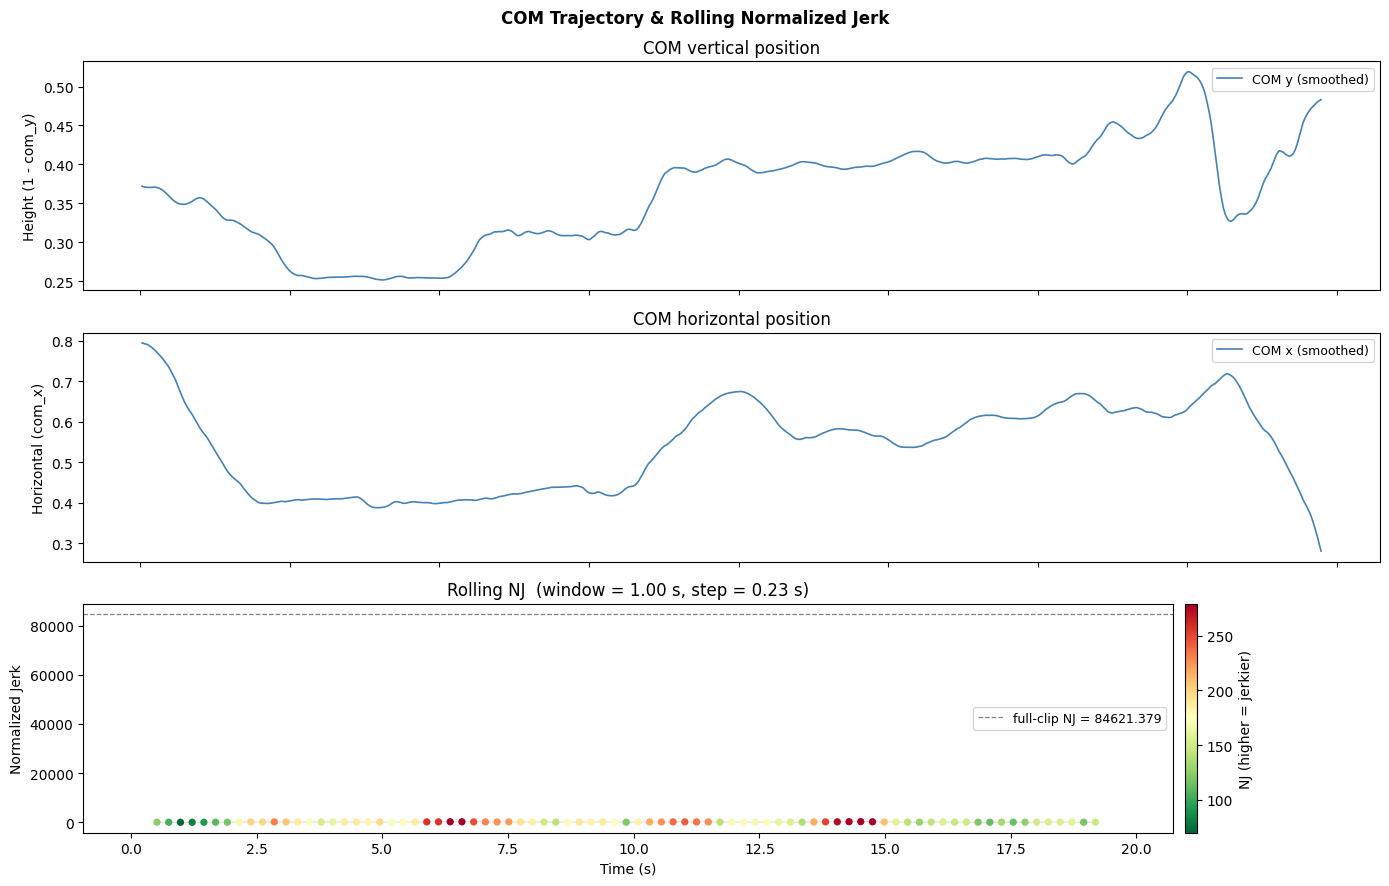

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# COM trajectory (y, flipped so up = higher on wall)
ax = axes[0]
ax.plot(t, 1 - com_valid['com_y'], color='steelblue', linewidth=1.2, label='COM y (smoothed)')
ax.set_ylabel('Height (1 - com_y)')
ax.set_title('COM vertical position')
ax.legend(fontsize=9)

# COM x
ax = axes[1]
ax.plot(t, com_valid['com_x'], color='steelblue', linewidth=1.2, label='COM x (smoothed)')
ax.set_ylabel('Horizontal (com_x)')
ax.set_title('COM horizontal position')
ax.legend(fontsize=9)

# Rolling NJ
ax = axes[2]
ax.axhline(nj_full, color='gray', linestyle='--', linewidth=0.9, label=f'full-clip NJ = {nj_full:.3f}')
sc = ax.scatter(window_tmid, window_nj, c=window_nj, cmap='RdYlGn_r',
                s=18, zorder=5, vmin=window_nj.min(), vmax=np.percentile(window_nj, 95))
ax.plot(window_tmid, window_nj, color='gray', linewidth=0.5, alpha=0.4)
plt.colorbar(sc, ax=ax, label='NJ (higher = jerkier)', pad=0.01)
ax.set_ylabel('Normalized Jerk')
ax.set_xlabel('Time (s)')
ax.set_title(f'Rolling NJ  (window = {WINDOW_FRAMES/FPS:.2f} s, step = {STEP_FRAMES/FPS:.2f} s)')
ax.legend(fontsize=9)

plt.suptitle('COM Trajectory & Rolling Normalized Jerk', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Segment comparison — first half vs second half

Full clip  NJ : 84621.3792  (592 frames, 19.70 s)
First half NJ : 21062.5316  (296 frames, 9.83 s)
Second half NJ: 20688.2314  (296 frames, 9.83 s)

→ second half is smoother


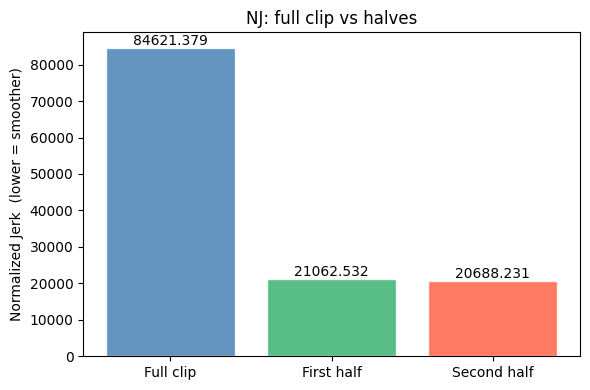

In [6]:
mid = len(com_valid) // 2

nj_first  = segment_jerk(com_valid, 0,   mid - 1,          FPS)
nj_second = segment_jerk(com_valid, mid, len(com_valid) - 1, FPS)

print(f'Full clip  NJ : {nj_full:.4f}  ({len(com_valid)} frames, {duration:.2f} s)')
print(f'First half NJ : {nj_first:.4f}  ({mid} frames, {t[mid-1]-t[0]:.2f} s)')
print(f'Second half NJ: {nj_second:.4f}  ({len(com_valid)-mid} frames, {t[-1]-t[mid]:.2f} s)')
print()
smoother = 'first half' if nj_first < nj_second else 'second half'
print(f'→ {smoother} is smoother')

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Full clip', 'First half', 'Second half']
values = [nj_full, nj_first, nj_second]
colors = ['steelblue', 'mediumseagreen', 'tomato']
bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Normalized Jerk  (lower = smoother)')
ax.set_title('NJ: full clip vs halves')
plt.tight_layout()
plt.show()

## 5. Synthetic sanity check

Validate the metric on known inputs:
- **Constant velocity** — jerk = 0 → NJ ≈ 0
- **Smooth sine** — moderate jerk → NJ > 0
- **Jittery** — same path + random noise → NJ >> smooth

In [7]:
def make_com(x: np.ndarray, y: np.ndarray, z: np.ndarray, fps: float = 30.0) -> pd.DataFrame:
    """Build a minimal COM DataFrame from coordinate arrays."""
    n = len(x)
    dt_ms = int(1000 / fps)
    return pd.DataFrame({
        'frame_idx':   np.arange(n, dtype=np.int32),
        'timestamp_ms': np.arange(n, dtype=np.int64) * dt_ms,
        'com_x': x.astype(np.float32),
        'com_y': y.astype(np.float32),
        'com_z': z.astype(np.float32),
    })


fps_synth = 30.0
n_synth   = 90   # 3 seconds
t_synth   = np.linspace(0, 3, n_synth)
rng       = np.random.default_rng(42)

# --- trajectories ---
com_const   = make_com(t_synth, np.zeros(n_synth),                         np.zeros(n_synth), fps_synth)
com_sine    = make_com(np.sin(2 * np.pi * t_synth), t_synth / 3,           np.zeros(n_synth), fps_synth)
com_jittery = make_com(
    np.sin(2 * np.pi * t_synth) + rng.normal(0, 0.15, n_synth),
    t_synth / 3                  + rng.normal(0, 0.05, n_synth),
    rng.normal(0, 0.05, n_synth),
    fps_synth,
)

nj_const   = normalized_jerk(com_const,   fps_synth)
nj_sine    = normalized_jerk(com_sine,    fps_synth)
nj_jittery = normalized_jerk(com_jittery, fps_synth)

print('Synthetic trajectory NJ values')
print(f'  Constant velocity : {nj_const:.6f}  (expect ≈ 0)')
print(f'  Smooth sine       : {nj_sine:.4f}')
print(f'  Jittery sine      : {nj_jittery:.4f}  (expect > smooth sine)')
print()
assert nj_const   < 0.01,          f'Expected near-zero NJ for constant velocity, got {nj_const}'
assert nj_jittery > nj_sine,       f'Expected jittery > smooth, got {nj_jittery} vs {nj_sine}'
print('Assertions passed.')

Synthetic trajectory NJ values
  Constant velocity : 0.002334  (expect ≈ 0)
  Smooth sine       : 266.5433
  Jittery sine      : 2097.2484  (expect > smooth sine)

Assertions passed.


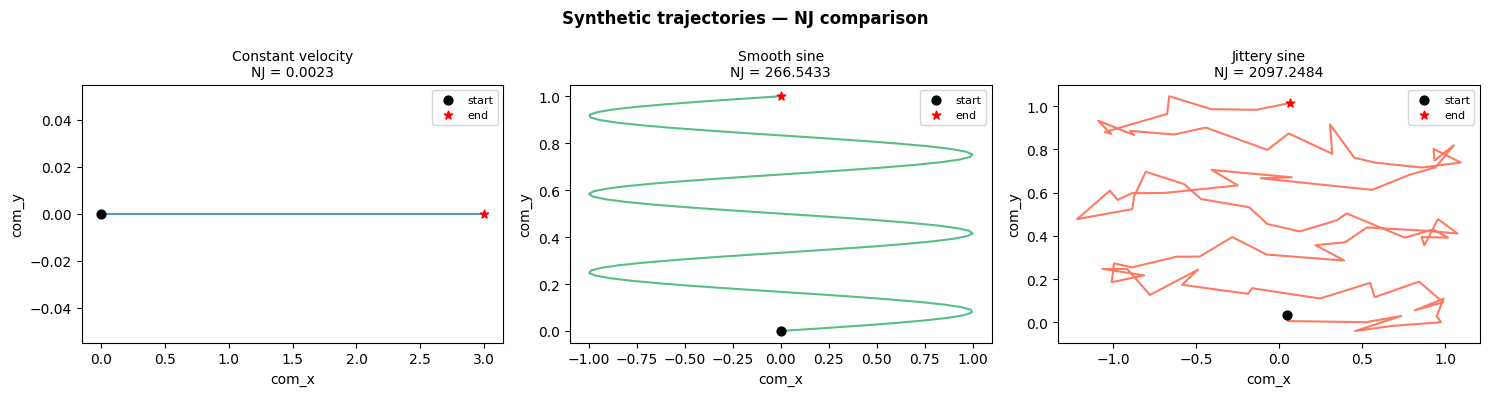

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

traj_data = [
    ('Constant velocity', com_const,   nj_const,   'steelblue'),
    ('Smooth sine',       com_sine,    nj_sine,    'mediumseagreen'),
    ('Jittery sine',      com_jittery, nj_jittery, 'tomato'),
]

for ax, (title, df, nj, color) in zip(axes, traj_data):
    ax.plot(df['com_x'], df['com_y'], color=color, linewidth=1.5, alpha=0.85)
    ax.scatter([df['com_x'].iloc[0]], [df['com_y'].iloc[0]],
               color='black', s=40, zorder=5, label='start')
    ax.scatter([df['com_x'].iloc[-1]], [df['com_y'].iloc[-1]],
               color='red', s=40, marker='*', zorder=5, label='end')
    ax.set_title(f'{title}\nNJ = {nj:.4f}', fontsize=10)
    ax.set_xlabel('com_x')
    ax.set_ylabel('com_y')
    ax.legend(fontsize=8)

plt.suptitle('Synthetic trajectories — NJ comparison', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. `segment_jerk` vs `normalized_jerk` equivalence

`segment_jerk(com, 0, len(com)-1, fps)` must equal `normalized_jerk(com, fps)` exactly.

In [9]:
n = len(com_valid)
nj_via_segment = segment_jerk(com_valid, 0, n - 1, FPS)
nj_via_full    = normalized_jerk(com_valid, FPS)

print(f'normalized_jerk         : {nj_via_full:.10f}')
print(f'segment_jerk (0, n-1)   : {nj_via_segment:.10f}')
print(f'Difference              : {abs(nj_via_full - nj_via_segment):.2e}')
assert np.isclose(nj_via_full, nj_via_segment, rtol=1e-10), 'Mismatch!'
print()
print('Equivalence confirmed (rtol=1e-10).')

normalized_jerk         : 84621.3791629779
segment_jerk (0, n-1)   : 84621.3791629779
Difference              : 0.00e+00

Equivalence confirmed (rtol=1e-10).


## 7. Short-segment edge case

Segments shorter than `MIN_FRAMES` must return `NaN`.

In [10]:
for n_frames in range(1, MIN_FRAMES + 2):
    t_short = np.linspace(0, 1, n_frames)
    df_short = make_com(t_short, np.zeros(n_frames), np.zeros(n_frames))
    nj_val = normalized_jerk(df_short, 30.0)
    tag = 'NaN (expected)' if n_frames < MIN_FRAMES else 'valid'
    print(f'  n={n_frames:2d} → NJ = {nj_val}  [{tag}]')

print(f'\nMIN_FRAMES = {MIN_FRAMES}')

  n= 1 → NJ = nan  [NaN (expected)]
  n= 2 → NJ = nan  [NaN (expected)]
  n= 3 → NJ = nan  [NaN (expected)]
  n= 4 → NJ = nan  [NaN (expected)]
  n= 5 → NJ = 0.0  [valid]
  n= 6 → NJ = 4.598036794488201e-07  [valid]

MIN_FRAMES = 5


## 8. Visual QA — kinematics overlay on footage

Write `kinematics_overlay.mp4` with per-frame:
- **Yellow dot + 1-second COM trail** — position on actual body
- **Top HUD** — current speed and rolling NJ (color-coded: green=smooth → red=jerky)
- **Bottom bar** — speed gauge

Then sample frames at the smoothest window, jerkiest window, and regular intervals.

In [ ]:
import cv2
import matplotlib.cm as cm
from collections import deque

from kinema.io.video import probe_video, iter_frames

VIDEO_PATH  = Path('../data/raw/VID-20260528-WA0044.mp4')
OUT_PATH_KI = DATA_DIR / 'VID-20260528-WA0044_kinematics_overlay.mp4'

meta = probe_video(VIDEO_PATH)
print(f'{meta.width}x{meta.height}  {meta.fps:.1f} fps  {meta.duration_sec:.1f}s')

# ── per-frame lookups ────────────────────────────────────────────────────────
# Speed: recompute from com_valid
_dt  = 1.0 / FPS
_vx2 = np.gradient(com_valid['com_x'].to_numpy(dtype=np.float64), _dt)
_vy2 = np.gradient(com_valid['com_y'].to_numpy(dtype=np.float64), _dt)
_vz2 = np.gradient(com_valid['com_z'].to_numpy(dtype=np.float64), _dt)
_spd2 = np.sqrt(_vx2**2 + _vy2**2 + _vz2**2)
_max_spd = float(np.nanmax(_spd2))

_frame_ids2 = com_valid['frame_idx'].to_numpy().tolist()
frame_to_spd2 = dict(zip(_frame_ids2, _spd2.tolist()))
frame_to_com2 = {
    int(fi): (float(cx), float(cy))
    for fi, cx, cy in zip(com_valid['frame_idx'], com_valid['com_x'], com_valid['com_y'])
}

# Rolling NJ: interpolate at any timestamp from window arrays
_nj_min, _nj_max = window_nj.min(), window_nj.max()

def _nj_at(ts: float) -> float:
    return float(np.interp(ts, window_tmid, window_nj))

def _nj_bgr(nj_val: float) -> tuple[int, int, int]:
    """RdYlGn_r: low NJ = green, high NJ = red."""
    frac = np.clip((nj_val - _nj_min) / max(_nj_max - _nj_min, 1e-9), 0.0, 1.0)
    r, g, b, _ = plt.cm.RdYlGn_r(float(frac))
    return (int(b * 255), int(g * 255), int(r * 255))


TRACE_FRAMES_KI = int(FPS)  # 1-second trail


def _draw_kinematics(
    frame_rgb: np.ndarray,
    fi: int,
    ts: float,
    trace: deque,
) -> np.ndarray:
    """Return BGR frame with kinematics HUD."""
    img = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]

    spd  = frame_to_spd2.get(fi, 0.0)
    nj   = _nj_at(ts)
    cpos = frame_to_com2.get(fi)
    nj_color = _nj_bgr(nj)

    # semi-transparent HUD
    strip = img.copy()
    cv2.rectangle(strip, (0, 0), (w, 90), (0, 0, 0), -1)
    img = cv2.addWeighted(strip, 0.55, img, 0.45, 0)

    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, f"speed = {spd:.4f}",     (12, 34), font, 0.85, (180, 220, 255), 2, cv2.LINE_AA)
    cv2.putText(img, f"NJ    = {nj:.1f}",       (12, 70), font, 0.85, nj_color,        2, cv2.LINE_AA)
    cv2.putText(img, f"t = {ts:.2f}s",          (w - 180, 34), font, 0.7, (160, 160, 160), 1, cv2.LINE_AA)

    # speed gauge
    bar_h = 14
    bar_w = int(w * min(spd / _max_spd, 1.0)) if _max_spd > 0 else 0
    cv2.rectangle(img, (0, h - bar_h), (w, h), (30, 30, 30), -1)
    cv2.rectangle(img, (0, h - bar_h), (bar_w, h), (180, 220, 255), -1)

    # COM trace + dot
    if cpos is not None and not (np.isnan(cpos[0]) or np.isnan(cpos[1])):
        cx, cy = int(cpos[0] * w), int(cpos[1] * h)
        trace.append((cx, cy))

    if len(trace) >= 2:
        pts = np.array(list(trace), dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(img, [pts], isClosed=False, color=(0, 220, 220), thickness=2)
    if trace:
        cv2.circle(img, trace[-1], 10, (0, 255, 255), -1)
        cv2.circle(img, trace[-1], 12, (0,   0,   0), 2)

    return img


# ── write video ──────────────────────────────────────────────────────────────
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUT_PATH_KI), fourcc, meta.fps, (meta.width, meta.height))
trace_ki: deque = deque(maxlen=TRACE_FRAMES_KI)

for fi, ts, frame_rgb in iter_frames(VIDEO_PATH):
    writer.write(_draw_kinematics(frame_rgb, fi, ts, trace_ki))

writer.release()
print(f'Written : {OUT_PATH_KI}')
print(f'Size    : {OUT_PATH_KI.stat().st_size / 1e6:.1f} MB')

In [ ]:
# ── sample key frames inline ─────────────────────────────────────────────────
# Show: smoothest window, jerkiest window, and frames at t=5,10,15s.

smoothest_t  = window_tmid[np.argmin(window_nj)]
jerkiest_t   = window_tmid[np.argmax(window_nj)]
regular_ts   = [5.0, 10.0, 15.0]

sample_specs: list[tuple[str, float]] = [
    (f'smoothest  NJ={window_nj.min():.0f}', smoothest_t),
    (f'jerkiest   NJ={window_nj.max():.0f}', jerkiest_t),
] + [(f't={ts_:.0f}s', ts_) for ts_ in regular_ts]

# Convert target timestamps → nearest frame indices
def _nearest_frame(ts_target: float) -> int:
    frame_ids_arr = np.array(_frame_ids2)
    ts_arr = com_valid['timestamp_ms'].to_numpy() / 1000.0
    idx = int(np.argmin(np.abs(ts_arr - ts_target)))
    return int(frame_ids_arr[idx])

sample_targets = {_nearest_frame(ts): lbl for lbl, ts in sample_specs}

captured_ki: dict[int, np.ndarray] = {}
trace_ki2: deque = deque(maxlen=TRACE_FRAMES_KI)

for fi, ts, frame_rgb in iter_frames(VIDEO_PATH):
    annotated_bgr = _draw_kinematics(frame_rgb, fi, ts, trace_ki2)
    if fi in sample_targets:
        captured_ki[fi] = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    if len(captured_ki) == len(sample_targets):
        break

# ordered display
sampled_ki = [
    (sample_targets[fi], captured_ki[fi])
    for fi in sorted(sample_targets)
    if fi in captured_ki
]

N_COLS_KI = 3
n_rows_ki = (len(sampled_ki) + N_COLS_KI - 1) // N_COLS_KI
fig, axes = plt.subplots(n_rows_ki, N_COLS_KI, figsize=(6 * N_COLS_KI, 5 * n_rows_ki))
axes_flat = np.array(axes).flatten()

for ax, (label, img) in zip(axes_flat, sampled_ki):
    ax.imshow(img)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axis('off')
for ax in axes_flat[len(sampled_ki):]:
    ax.set_visible(False)

plt.suptitle('Kinematics Overlay — Key Frame QA\n(NJ text: green=smooth, red=jerky)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Full annotated video: {OUT_PATH_KI.name}')